In [1]:
import numpy as np

# np.random.seed(0)
# X = np.random.uniform(-2,3,(3,4))
# print(X)

In [9]:
# !pip install nnfs

(300, 2)


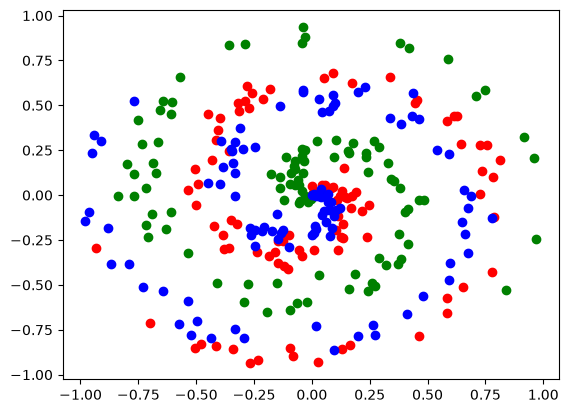

In [ ]:
import nnfs
from nnfs.datasets import spiral_data
import matplotlib.pyplot as plt
nnfs.init() 
X,y = spiral_data(100,3)
print(X.shape)
plt.scatter(X[:100,0],X[:100,1],color='r')
plt.scatter(X[100:200,0],X[100:200,1],color='g')
plt.scatter(X[200:300,0],X[200:300,1],color='b')
plt.show()

In [ ]:

class Layer_Dense:

    def __init__(self,inputs,n_neurons):
        # self.weights = 0.10 * np.random.randn(inputs,n_neurons)  # not need for tranpose
        self.weights = np.random.randn(inputs,n_neurons) * np.sqrt(2/inputs) # he initialization

        self.biases = np.zeros((1,n_neurons))

    def forward(self,inputs):
        self.inputs = inputs
        self.output = np.dot(inputs,self.weights) + self.biases

    def backward(self,dvalues):
        self.dweights = self.inputs.T @ dvalues
        self.dbiases = np.sum(dvalues,axis=0,keepdims=True)
        self.dinputs = dvalues @ self.weights.T

class Activation_ReLU:
    def forward(self,inputs):
        self.inputs = inputs
        self.output =  np.maximum(0,inputs)

    def backward(self,dvalues):

        self.dinputs = dvalues.copy()
        self.dinputs[self.inputs<=0] = 0

class Activation_Softmax:
    def forward(self,inputs):
        exp_values = np.exp(inputs - np.max(inputs,axis=1,keepdims=True))  # e^0 = 1 which becomes the highest probability 
        probabilites = exp_values / np.sum(exp_values,axis=1,keepdims=True)
        self.output = probabilites

    def backward(self,dvalues):
        '''dvalues from the previous CCE values'''

        self.dinputs = np.empty_like(dvalues)

        for index,(single_output,single_dvalues) in enumerate(zip(self.output,dvalues)):

            single_output = single_output.reshape(-1,1)

            jacobian_matrix = (
                np.diagflat(single_output)
                -
                np.dot(single_output,single_output.T)
            )
            self.dinputs[index] = (jacobian_matrix @ single_dvalues)

class Loss:
    def calculate(self,output,y):
        sample_losses = self.forward(output,y)
        data_loss = np.mean(sample_losses)
        return data_loss
class Loss_CategoricalCrossentropy(Loss):

    '''categorical cross entropy for forward direction

        cross entropy = -log(probability)
    
    '''
    def forward(self,y_pred,y_true):
        sample = len(y_pred)
        '''
        The inf problem happens because of this part of cross-entropy:
        loss=−log(p_correct)
        If the model gives the correct class a probability of exactly 0:
        correct_confidence = 0.0
        then:
        −log(0)
        is undefined. As x approaches 0:
        log(x)→−∞
        so:
        −log(x)→+∞



        1e-7 protects us from exactly 0.
        1 - 1e-7 protects us from exactly 1.

        np.clip(y_pred, 1e-7, 1 - 1e-7)
        means:
        minimum allowed = 0.0000001
        maximum allowed = 0.9999999
        So:
        np.clip([0.0, 0.2, 0.7, 1.0],1e-7,1 - 1e-7)
        becomes: [0.0000001, 0.2, 0.7, 0.9999999]
        '''

        '''np.clip() limits the values of an array within a specified minimum and maximum threshold.'''


        y_pred_clipped = np.clip(y_pred,1e-7,1-1e-7)

        if len(y_true.shape)==1:
            correct_confidences = y_pred_clipped[range(sample),y_true]
        elif len(y_true.shape)==2:
            correct_confidences = np.sum(y_pred_clipped * y_true,axis=1)

        self.negative_log_likelihoods = -np.log(correct_confidences)
        return self.negative_log_likelihoods

    def backward(self,dvalues,y_true):
        '''dvalues are the probability produced by the softmax function'''
        sample = len(dvalues) # size of dvalues
        labels=len(dvalues[0]) # size of sample 1 dvalue

        if len(y_true.shape)==1:
            '''a quite elegant and efficient way to give the true values
            example 
            dvalues  = array(
                            [0.2,0.7,0.1],
                            [0.8,0.1,0.1])
            if we have labels 3 then eye matrix is
            [[1,0,0],
            [0,1,0],
            [0,0,1]]
            if our true values be like [1,0,1]
            then it only selects the rows of that label which is row1, row0, row1
            '''
            y_true = np.eye(labels)[y_true]

        self.dinputs = -y_true/dvalues
        '''in foward loss we are taking the mean loss across all samples
        now differentiating that mean is a cost it comes out during derivation so we divide it by
        mean or total number of samples
        '''
        self.dinputs = self.dinputs/sample
        
class Optimizer_SGD:

    def __init__(self,learning_rate=1.0,decay=0.0):
        self.learning_rate = learning_rate
        self.current_learning_rate = self.learning_rate
        self.decay = decay
        self.iterations = 0

    def pre_update_params(self):
        
        if self.decay:
            self.current_learning_rate = (self.learning_rate / (1 + (self.current_learning_rate * self.iterations)))# decay learning rate 

    def update_params(self,layer):
        layer.weights -= (self.current_learning_rate * layer.dweights)
        layer.biases -= (self.current_learning_rate * layer.dbiases)

    def post_update_params(self):
        self.iterations +=1


dense1 = Layer_Dense(2,64)
activation1 = Activation_ReLU()

dense2 = Layer_Dense(64,64)
activation2 = Activation_ReLU()

dense3 = Layer_Dense(64,3)
activation3 = Activation_Softmax()

loss_function =  Loss_CategoricalCrossentropy()
optimizer = Optimizer_SGD(learning_rate=0.1)
# f_loss=[]
# f_accuracy=[]

for epoch in range(10001):

    dense1.forward(X)
    activation1.forward(dense1.output)

    dense2.forward(activation1.output)
    activation2.forward(dense2.output)

    dense3.forward(activation2.output)
    activation3.forward(dense3.output)

    # LOSS
    loss = loss_function.calculate(activation3.output,y)

    # ACCURACY
    predictions = np.argmax(activation3.output,axis=1)

    accuracy = np.mean(predictions == y)

    # f_loss.append(loss)
    # f_accuracy.append(accuracy)

    # -----------------------
    # BACKWARD
    # -----------------------

    # CCE
    loss_function.backward(activation3.output,y)

    # Softmax
    activation3.backward(loss_function.dinputs)

    # dense 3
    dense3.backward(activation3.dinputs)
    
    # Dense2
    activation2.backward(dense3.dinputs)
    dense2.backward(activation2.dinputs)

    # ReLU
    activation1.backward(dense2.dinputs)

    # Dense1
    dense1.backward(activation1.dinputs )


    optimizer.pre_update_params()
    optimizer.update_params(dense1)
    optimizer.update_params(dense2)
    optimizer.update_params(dense3)
    optimizer.post_update_params()

    if epoch % 100 == 0:
        print("epoch:", epoch,"loss:", loss,"accuracy:", accuracy)



epoch: 0 loss: 1.174589 accuracy: 0.3333333333333333
epoch: 100 loss: 1.0472083 accuracy: 0.47333333333333333
epoch: 200 loss: 1.0334442 accuracy: 0.49666666666666665
epoch: 300 loss: 1.0209888 accuracy: 0.5166666666666667
epoch: 400 loss: 1.0107068 accuracy: 0.52
epoch: 500 loss: 1.0016841 accuracy: 0.5133333333333333
epoch: 600 loss: 0.99293846 accuracy: 0.5166666666666667
epoch: 700 loss: 0.9843413 accuracy: 0.5166666666666667
epoch: 800 loss: 0.97589093 accuracy: 0.52
epoch: 900 loss: 0.9670058 accuracy: 0.54
epoch: 1000 loss: 0.95795286 accuracy: 0.5366666666666666
epoch: 1100 loss: 0.94856733 accuracy: 0.5466666666666666
epoch: 1200 loss: 0.93858683 accuracy: 0.5666666666666667
epoch: 1300 loss: 0.92607045 accuracy: 0.5766666666666667
epoch: 1400 loss: 0.91352236 accuracy: 0.5833333333333334
epoch: 1500 loss: 0.8997821 accuracy: 0.5966666666666667
epoch: 1600 loss: 0.8834791 accuracy: 0.6066666666666667
epoch: 1700 loss: 0.8643697 accuracy: 0.6166666666666667
epoch: 1800 loss: 0.

In [ ]:
import matplotlib.pyplot as plt

